In [1]:
! pip install yfinance

  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import yfinance as yf
import pandas as pd

# 1. Define tickers and their sectors for your report
sector_map = {
    'AAPL': 'Technology',
    'TSLA': 'Consumer Discretionary',
    'AMZN': 'Consumer Discretionary',
    'XOM' : 'Energy',
    'KO'  : 'Consumer Staples',
    'GLD' : 'Safe Haven (Gold)'
}

tickers = list(sector_map.keys())

# 2. Download Data (2023 to March 2026)
print("Downloading multi-sector data...")
data = yf.download(tickers, start='2023-01-01', end='2026-03-16')['Close']

# 3. Data Cleaning: Remove any missing values
data = data.dropna()

# 4. Feature Engineering: Calculate Daily Returns
# This is a key requirement for 'Advanced' projects
returns = data.pct_change().dropna() # pct_change() calculates daily returns, dropna() removes the first row which will be NaN

# 5. Save everything to one clean CSV
# We will save the prices, but keep the sector map in mind for your writing
data.to_csv('final_stock_data.csv')
print("Success! 'final_stock_data.csv' is ready for analysis.")

[*********************100%***********************]  6 of 6 completed

Success! 'final_stock_data.csv' is ready for analysis.


1. Display first 10 rows of the stock dataset.

In [ ]:
df = pd.read_csv('final_stock_data.csv', index_col=0, parse_dates=True) # parse_dates=True ensures the index is treated as datetime
print("First 10 rows of the stock dataset:")
print(df.head(10).to_string())


First 10 rows of the stock dataset:
                  AAPL       AMZN         GLD         KO        TSLA         XOM
Date                                                                            
2023-01-03  123.096031  85.820000  171.059998  57.126354  108.099998   95.434196
2023-01-04  124.365654  85.139999  172.669998  57.099125  113.639999   95.711967
2023-01-05  123.046806  83.120003  170.520004  56.445736  110.339996   97.853432
2023-01-06  127.574203  86.080002  173.710007  57.534721  113.059998   99.036163
2023-01-09  128.095856  87.360001  174.100006  56.817810  119.769997   97.190376
2023-01-10  128.666656  89.870003  174.740005  56.382214  118.849998   98.641914
2023-01-11  131.383133  95.089996  174.619995  56.273312  123.220001   99.788811
2023-01-12  131.304398  95.269997  176.639999  55.547329  123.559998  101.446442
2023-01-13  132.633072  98.120003  178.759995  55.746971  122.400002  101.383728
2023-01-17  133.794479  96.050003  177.589996  55.973835  131.490005  101

2. How many rows and columns are present in the CSV file?

In [9]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset contains 801 rows and 6 columns.


3. List all the unique stock tickers (column names) available in the dataset.

In [ ]:
print("Available stock tickers in the dataset:")
print(df.columns.tolist())


Available stock tickers in the dataset:
['AAPL', 'AMZN', 'GLD', 'KO', 'TSLA', 'XOM']


4.  Display only the data for AAPL and TSLA.

In [ ]:
print("Data for AAPL and TSLA:")
print(df[['AAPL', 'TSLA']].head(10).to_string())

Data for AAPL and TSLA:
                  AAPL        TSLA
Date                              
2023-01-03  123.096031  108.099998
2023-01-04  124.365654  113.639999
2023-01-05  123.046806  110.339996
2023-01-06  127.574203  113.059998
2023-01-09  128.095856  119.769997
2023-01-10  128.666656  118.849998
2023-01-11  131.383133  123.220001
2023-01-12  131.304398  123.559998
2023-01-13  132.633072  122.400002
2023-01-17  133.794479  131.490005


5. What is the exact closing price of KO on the very first day of the dataset?

In [42]:
ko_firstprice = df['KO'].iloc[0]
print(f"Closing price of KO on the first day: {ko_firstprice}")

Closing price of KO on the first day: 57.1263542175293


6. Find the maximum price reached by XOM in the entire period.

In [43]:
xom_maxprice = df['XOM'].max()
print(f"Maximum price of XOM during the period: {xom_maxprice}")

Maximum price of XOM during the period: 156.1199951171875


7. Find the minimum price of AMZN recorded in the CSV.

In [44]:
amzn_minprice = df['AMZN'].min()
print(f"Minimum price of AMZN during the period: {amzn_minprice}")

Minimum price of AMZN during the period: 83.12000274658203


8. Check if there are any null (missing) values in the dataset.

In [ ]:
null_counts = df.isnull().sum()
print("Null values in each column: ")
print(null_counts)

Null values in each column: 
AAPL    0
AMZN    0
GLD     0
KO      0
TSLA    0
XOM     0
dtype: int64


9. What is the average (mean) price of GLD over the 3-year period?

In [45]:
gld_meanprice = df['GLD'].mean()
print(f"Average price of GLD over the period: {gld_meanprice}")

Average price of GLD over the period: 252.8551435149118


10. Slice the data to show only the stock prices for the month of January 2024.

In [46]:
january2024 = df['2024-01-01':'2024-01-31']
print("Stock prices for January 2024:")
print(january2024.to_string())


Stock prices for January 2024:
                  AAPL        AMZN         GLD         KO        TSLA        XOM    Tech_Sum
Date                                                                                        
2024-01-02  183.731308  149.929993  190.720001  55.998600  248.419998  94.847115  333.661301
2024-01-03  182.355591  148.470001  189.130005  56.129650  238.449997  95.644005  330.825592
2024-01-04  180.039658  144.570007  189.320007  55.942432  237.929993  94.810059  324.609665
2024-01-05  179.317169  145.240005  189.350006  55.858181  237.490005  95.097298  324.557175
2024-01-08  183.652130  149.100006  187.869995  56.270073  240.449997  93.512817  332.752136
2024-01-09  183.236435  151.369995  187.929993  56.167099  234.960007  92.354553  334.606430
2024-01-10  184.275681  153.729996  187.500000  56.354321  233.940002  91.446487  338.005676
2024-01-11  183.681839  155.179993  187.869995  55.989243  227.220001  91.427948  338.861832
2024-01-12  184.008423  154.619995  189

11. Calculate the total price difference for AAPL between the start and end of the dataset.

In [47]:
aapl_pricediff = df['AAPL'].iloc[-1] - df['AAPL'].iloc[0]
print(f"Total price difference for AAPL from start to end: {aapl_pricediff}")

Total price difference for AAPL from start to end: 127.02396392822266


12.  Identify the dates where TSLA price was greater than $200 and how many times it occurred.

In [48]:
tsla_above200 = df[df['TSLA'] > 200].index
print("Dates when TSLA price was greater than $200:")

tsla_dates_series = pd.Series(tsla_above200.strftime('%Y-%m-%d').tolist())
print(tsla_dates_series.to_string(index=False))
print(f"\nNumber of times TSLA price was greater than $200: {len(tsla_above200)}")

Dates when TSLA price was greater than $200:
2023-02-08
2023-02-09
2023-02-14
2023-02-15
2023-02-16
2023-02-17
2023-02-22
2023-02-23
2023-02-27
2023-02-28
2023-03-01
2023-03-31
2023-05-30
2023-05-31
2023-06-01
2023-06-02
2023-06-05
2023-06-06
2023-06-07
2023-06-08
2023-06-09
2023-06-12
2023-06-13
2023-06-14
2023-06-15
2023-06-16
2023-06-20
2023-06-21
2023-06-22
2023-06-23
2023-06-26
2023-06-27
2023-06-28
2023-06-29
2023-06-30
2023-07-03
2023-07-05
2023-07-06
2023-07-07
2023-07-10
2023-07-11
2023-07-12
2023-07-13
2023-07-14
2023-07-17
2023-07-18
2023-07-19
2023-07-20
2023-07-21
2023-07-24
2023-07-25
2023-07-26
2023-07-27
2023-07-28
2023-07-31
2023-08-01
2023-08-02
2023-08-03
2023-08-04
2023-08-07
2023-08-08
2023-08-09
2023-08-10
2023-08-11
2023-08-14
2023-08-15
2023-08-16
2023-08-17
2023-08-18
2023-08-21
2023-08-22
2023-08-23
2023-08-24
2023-08-25
2023-08-28
2023-08-29
2023-08-30
2023-08-31
2023-09-01
2023-09-05
2023-09-06
2023-09-07
2023-09-08
2023-09-11
2023-09-12
2023-09-13
2023-09-1

13. Create a new column 'Tech_Sum' which is the addition of AAPL and AMZN prices

In [ ]:
df['Tech_Sum'] = df['AAPL'] + df['AMZN']
print("First 5 rows with the new 'Tech_Sum' column:")
print(df.head(5).to_string())

First 5 rows with the new 'Tech_Sum' column:
                  AAPL       AMZN         GLD         KO        TSLA        XOM    Tech_Sum
Date                                                                                       
2023-01-03  123.096031  85.820000  171.059998  57.126354  108.099998  95.434196  208.916031
2023-01-04  124.365654  85.139999  172.669998  57.099125  113.639999  95.711967  209.505653
2023-01-05  123.046806  83.120003  170.520004  56.445736  110.339996  97.853432  206.166809
2023-01-06  127.574203  86.080002  173.710007  57.534721  113.059998  99.036163  213.654205
2023-01-09  128.095856  87.360001  174.100006  56.817810  119.769997  97.190376  215.455856


14. Sort the dataset based on XOM prices in descending order.

In [49]:
sorted_byxom = df.sort_values(by='XOM', ascending=False)
print("Top 5 rows sorted by XOM price in descending order:")
print(sorted_byxom.head(5).to_string())

Top 5 rows sorted by XOM price in descending order:
                  AAPL        AMZN         GLD         KO        TSLA         XOM    Tech_Sum
Date                                                                                         
2026-03-13  250.119995  207.669998  460.839996  77.339996  391.200012  156.119995  457.789993
2026-02-11  275.500000  204.080002  467.630005  78.063240  428.269989  154.529999  479.580002
2026-03-02  264.720001  208.389999  490.000000  79.672180  403.320007  154.220001  473.110001
2026-03-12  255.759995  209.529999  466.880005  77.080002  395.010010  153.529999  465.289993
2026-02-27  264.179993  210.000000  483.750000  81.003021  402.510010  152.500000  474.179993


15. On how many days did KO close above its average price?

In [50]:
ko_avgprice = df['KO'].mean()
ko_aboveavg = df[df['KO'] > ko_avgprice]
print(f"Number of days KO closed above its average price: {ko_aboveavg.shape[0]}")

Number of days KO closed above its average price: 351


16. Find the 5 dates with the highest trading prices for AMZN.

In [51]:
topamzn = df['AMZN'].nlargest(5)
print("Top 5 dates with the highest AMZN prices:")
print(topamzn.index.strftime('%Y-%m-%d').tolist())

Top 5 dates with the highest AMZN prices:
['2025-11-03', '2025-11-05', '2025-11-04', '2025-11-11', '2025-11-10']


17. Calculate the median price for all stocks and compare them.

In [52]:
median_prices = df.median()
print("Median prices for all stocks:")
print(median_prices.to_string())

Median prices for all stocks:
AAPL        201.766006
AMZN        184.710007
GLD         226.199997
KO           60.315292
TSLA        251.919998
XOM         105.735130
Tech_Sum    395.455368


18. Filter the rows where GLD price was between $180 and $200.

In [53]:
gld_between_180to200 = df[(df['GLD'] >= 180) & (df['GLD'] <= 200)]
print("Rows where GLD price was between $180 and $200:")
print(gld_between_180to200.to_string())
print(f"\nNumber of days GLD price was between $180 and $200: {gld_between_180to200.shape[0]}")

Rows where GLD price was between $180 and $200:
                  AAPL        AMZN         GLD         KO        TSLA         XOM    Tech_Sum
Date                                                                                         
2023-01-24  140.280457   96.320000  180.279999  54.948380  143.889999  101.975090  236.600456
2023-01-25  139.621002   97.180000  181.110001  55.293224  144.429993  101.437485  236.801003
2023-02-01  143.134705  105.150002  181.669998  55.656219  181.410004  102.808380  248.284706
2023-03-17  152.786560   98.949997  183.770004  54.885201  180.130005   90.146172  251.736557
2023-03-20  155.152283   97.709999  183.839996  55.415585  183.250000   92.502762  252.862282
2023-03-21  157.005417  100.610001  180.369995  55.159538  197.580002   96.647087  257.615417
2023-03-22  155.576172   98.699997  183.440002  54.912640  191.149994   94.434982  254.276169
2023-03-23  156.660431   98.709999  185.740005  54.793762  192.220001   93.369560  255.370430
2023-03-24  

19. What is the standard deviation (risk) of TSLA's price?

In [54]:
tsla_std = df['TSLA'].std()
print(f"Standard deviation (risk) of TSLA's price: {tsla_std}")


Standard deviation (risk) of TSLA's price: 93.30890721785718


20. Calculate the 7-day rolling average for AAPL to smooth out the trend.

In [ ]:
# 7 day rolling average means we take the average of the current day and the previous 6 days to get a smoothed value for each day. This helps to identify trends by reducing the noise from daily price fluctuations.
aapl_rollingavg = df['AAPL'].copy() 
for i in range(6, len(df)):
    aapl_rollingavg.iloc[i] = df['AAPL'].iloc[i-6:i+1].mean()
print("First 10 values of the 7-day rolling average for AAPL:")
print(aapl_rollingavg.head(10).to_string())

First 10 values of the 7-day rolling average for AAPL:
Date
2023-01-03    123.096031
2023-01-04    124.365654
2023-01-05    123.046806
2023-01-06    127.574203
2023-01-09    128.095856
2023-01-10    128.666656
2023-01-11    126.604049
2023-01-12    127.776672
2023-01-13    128.957732
2023-01-17    130.493114


21. Manually calculate the daily return of AAPL using (Today - Yesterday) / Yesterday logic with .iloc.

In [58]:
aapl_dailyreturn = df['AAPL'].copy()
for i in range(1, len(df)):
    aapl_dailyreturn.iloc[i] = (df['AAPL'].iloc[i] - df['AAPL'].iloc[i-1]) / df['AAPL'].iloc[i-1]
print("First 10 values of the daily return for AAPL:")
print(aapl_dailyreturn.head(10).to_string())

First 10 values of the daily return for AAPL:
Date
2023-01-03    123.096031
2023-01-04      0.010314
2023-01-05     -0.010605
2023-01-06      0.036794
2023-01-09      0.004089
2023-01-10      0.004456
2023-01-11      0.021113
2023-01-12     -0.000599
2023-01-13      0.010119
2023-01-17      0.008757


22. Find the date when the "Price Gap" (today's price minus yesterday's price) was the highest for TSLA.

In [60]:
tsla_pricegap = df['TSLA'].copy()
for i in range(1, len(df)):
    tsla_pricegap.iloc[i] = df['TSLA'].iloc[i] - df['TSLA'].iloc[i-1]
max_gapindex = tsla_pricegap.idxmax()
print(f"Date with the highest price gap for TSLA: {max_gapindex.strftime('%Y-%m-%d')}")

Date with the highest price gap for TSLA: 2023-01-03


23. Group the data by Year and find the average price of each stock per year.

In [ ]:
df['Year'] = df.index.year
yearlyavg = df.groupby('Year').mean()
print("Yearly Average Prices:")
print(yearlyavg.to_string())

Yearly Average Prices:
            AAPL        AMZN         GLD         KO        TSLA         XOM    Tech_Sum
Year                                                                                   
2023  170.351416  121.372800  180.449880  55.050826  217.475240   98.935618  291.724216
2024  205.646687  184.628691  221.099484  60.724704  230.614961  107.032266  390.275377
2025  231.563040  217.672800  317.911360  67.589118  356.970760  108.573410  449.235840
2026  262.396366  223.152653  453.665104  75.048089  420.051020  141.186307  485.549019


24. Compare the volatility of KO (Staples) vs TSLA (Discretionary) using a bar chart.

Volatility (std of daily returns) of KO: 0.0094036735006524
Volatility (std of daily returns) of TSLA: 0.03707040838831924


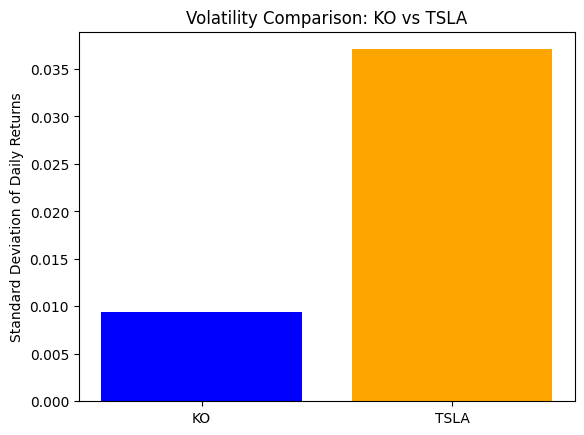

In [ ]:
# volatility can be measured by standard deviation of daily returns
volatility_ko = returns['KO'].std()
volatility_tsla = returns['TSLA'].std()
print(f"Volatility (std of daily returns) of KO: {volatility_ko}")
print(f"Volatility (std of daily returns) of TSLA: {volatility_tsla}")

# bar chart plotting 
import matplotlib.pyplot as plt
plt.bar(['KO', 'TSLA'], [volatility_ko, volatility_tsla], color=['blue', 'orange'])
plt.title('Volatility Comparison: KO vs TSLA')
plt.ylabel('Standard Deviation of Daily Returns')
plt.show()

25. Identify "Crash Days" where AMZN dropped by more than $5 in a single day.

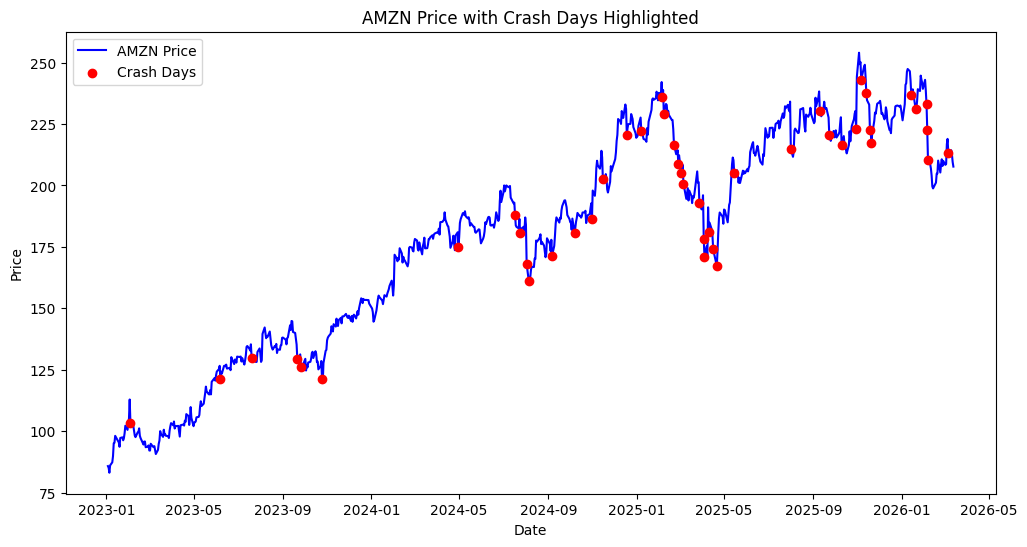

In [ ]:
amzn_pricegap = df['AMZN'].copy()
for i in range(1, len(df)):
    amzn_pricegap.iloc[i] = df['AMZN'].iloc[i] - df['AMZN'].iloc[i-1]
crashdays = amzn_pricegap[amzn_pricegap < -5].index

plt.figure(figsize=(12,6))
plt.plot(df.index, df['AMZN'], label='AMZN Price', color='blue')
plt.scatter(crashdays, df.loc[crashdays, 'AMZN'], color='red', label='Crash Days', zorder=5)
plt.title('AMZN Price with Crash Days Highlighted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()



26. Plot a multi-line graph comparing the trends of all 6 stocks.

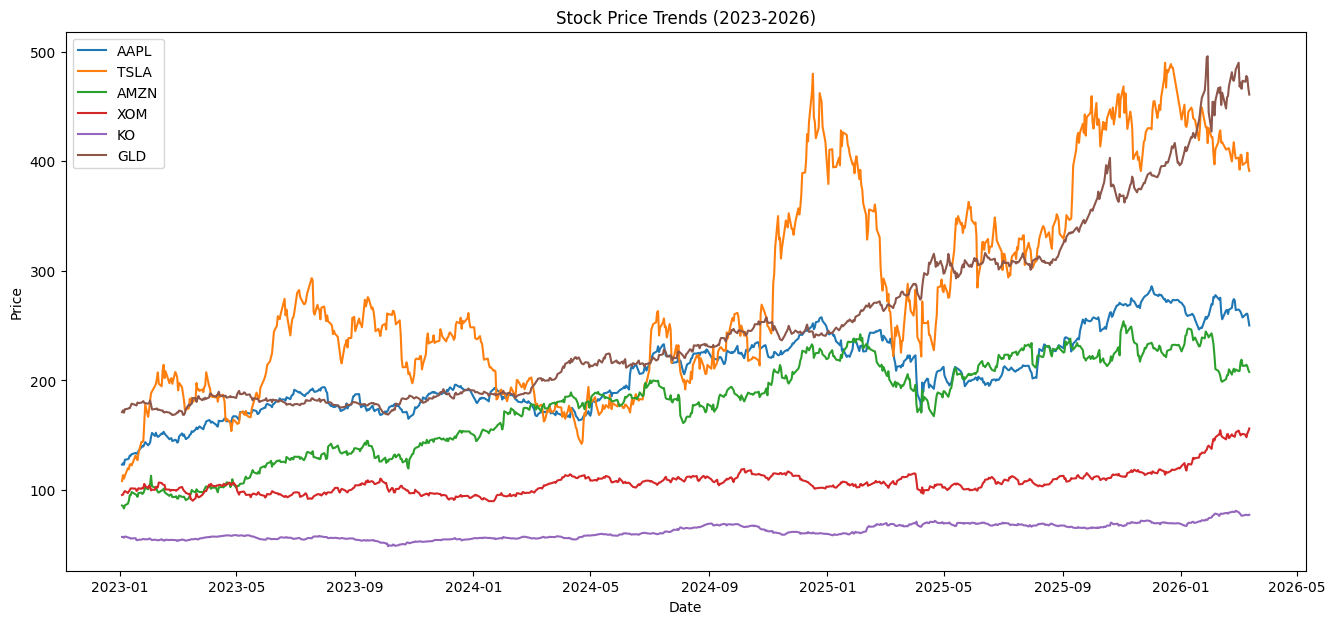

In [ ]:
plt.figure(figsize=(16,7))
for ticker in tickers:
    plt.plot(df.index, df[ticker], label=ticker)
plt.title('Stock Price Trends (2023-2026)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

27. Create a subset of data containing only "Mondays" and find the average return.

In [ ]:
mondays = df[df.index.weekday == 0] # 0 corresponds to Monday
mondays_returns = mondays.diff().dropna()
print("First 10 values of the Monday price differences:")
print(mondays_returns.head(10).to_string())

First 10 values of the Monday price differences:
                 AAPL       AMZN       GLD        KO       TSLA       XOM   Tech_Sum  Year
Date                                                                                      
2023-01-23  10.787033  10.159996  5.529999 -2.159824  23.980003  3.843887  20.947029   0.0
2023-01-30   1.860138   3.030006 -0.870010  0.372066  22.910004  0.716812   4.890144   0.0
2023-02-06   8.592209   1.629997 -4.939987 -0.426510  28.099991 -1.639694  10.222206   0.0
2023-02-13   2.317734  -2.639999 -1.340012  0.390213  -0.119995  6.250977  -0.322266   0.0
2023-02-27  -5.845322  -5.779999 -3.470001 -0.707836  12.990005 -6.546043 -11.625320   0.0
2023-03-06   5.825638  -0.010002  2.610001  0.490044 -13.820007  2.943459   5.815636   0.0
2023-03-13  -3.312027  -1.320000  6.240005 -0.499119 -19.330002 -6.564133  -4.632027   0.0
2023-03-20   6.831024   5.279999  5.979996  1.138741   8.770004 -3.692879  12.111023   0.0
2023-03-27   0.867432   0.330002 -1.88999

28. Calculate the 30-day Moving Average for XOM and plot it against the actual price.

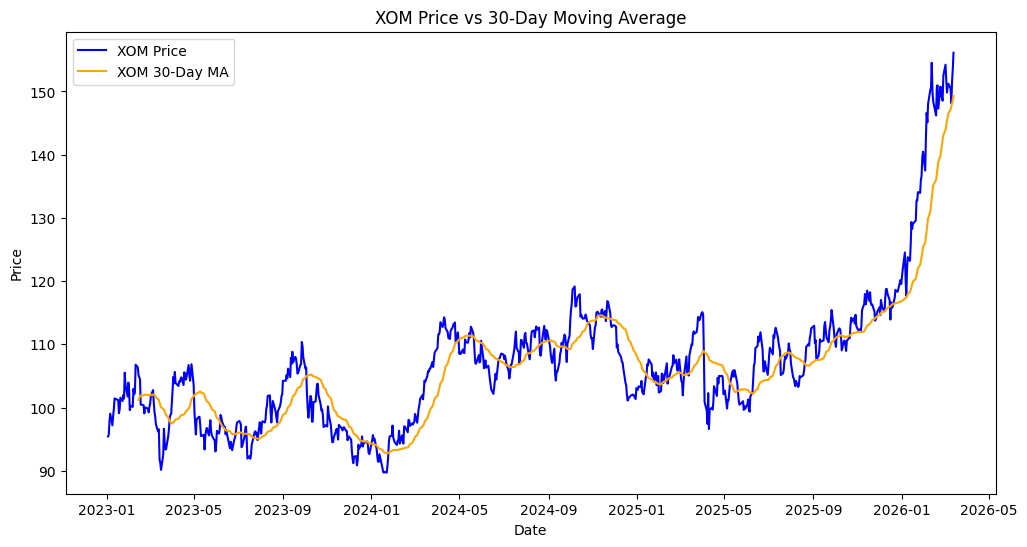

In [ ]:
xom_30ma = df['XOM'].rolling(window=30).mean()
plt.figure(figsize=(12,6))
plt.plot(df.index, df['XOM'], label='XOM Price', color='blue')
plt.plot(df.index, xom_30ma, label='XOM 30-Day MA', color='orange')
plt.title('XOM Price vs 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()